**Author:** Biswajit Jana
**Date:** July 10, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-03-tess-rrlyrae-asteroseismology/notebook.ipynb)

# TESS light curve of RR Lyrae itself: recovering the pulsation period, and looking for the Blazhko effect

**Archive:** mast
**Date:** 2026-08-03
**Scientific question:** Using real TESS light curves of RR Lyrae (the prototype of its own class of pulsating star), can a blind period search recover its well-known 0.5668-day pulsation period, and is there evidence of the star's famous long-term amplitude modulation (the Blazhko effect) in these data?

## Learning goals

By the end of this notebook you will be able to:

- Retrieve real TESS light curves for a specific, named star across multiple sectors directly
  from MAST via `lightkurve`/`astroquery`.
- Run a real Lomb-Scargle period search on real photometric time-series data and compare the
  recovered period against a well-established literature value.
- Fold a real light curve on its recovered period to see the pulsation shape.
- Understand a genuine, disclosed data-quality limitation: very bright stars can saturate a
  space telescope's detector, and see how that shows up in, and limits, an automated pipeline
  photometry product.

**Background:** RR Lyrae is the naked-eye variable star that gave its name to an entire class of
pulsating horizontal-branch stars used as standard candles for distances in globular clusters and
the Galactic halo. It pulsates with a fundamental-mode period of about 0.5668 days and is also the
star in which the "Blazhko effect" -- a slow, roughly 40-day modulation of the pulsation amplitude
and phase, still not fully explained by theory -- was first discovered (Blazhko, 1907). Because
this exact star is so well studied, it is a strong real test case: if a fresh period search on
real TESS data cannot recover its already-known period, something in the method is wrong.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import scienceplots
    plt.style.use(["science", "no-latex"])
except Exception:
    plt.style.use("seaborn-v0_8-whitegrid")
from astropy.timeseries import LombScargle

warnings.filterwarnings("ignore", category=RuntimeWarning)
COLORS = {"navy": "#071426", "blue": "#4cc9f0", "cyan": "#72efdd",
          "gold": "#ffca58", "orange": "#ff7b54", "pink": "#ef5da8", "violet": "#8f5cff"}
print("Environment ready.")

Environment ready.


## Real data: three TESS sectors of RR Lyrae (TIC 159717514)

I query MAST for all available TESS 2-minute-cadence SPOC light curves of RR Lyrae. Three real
sectors come back: Sector 14 (2019) and the consecutive Sectors 40 and 41 (2021, giving a
continuous ~56-day baseline) -- useful for a long-period modulation search.

In [2]:
import lightkurve as lk

search = lk.search_lightcurve("RR Lyrae", mission="TESS", author="SPOC")
print(search)
light_curves = search.download_all()

per_sector = {}
for lc in light_curves:
    clean = lc[lc.quality == 0].remove_nans()
    flux = np.asarray(clean.flux.value)
    time = np.asarray(clean.time.value)
    norm_flux = flux / np.nanmedian(flux)
    per_sector[lc.sector] = (time, norm_flux)
    print(f"Sector {lc.sector}: {len(time)} good cadences, "
          f"{time.min():.1f}-{time.max():.1f} TBJD, flux range {norm_flux.min():.2f}-{norm_flux.max():.2f}")

SearchResult containing 3 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 14 2019   SPOC     120   159717514      0.0
  1 TESS Sector 40 2021   SPOC     120   159717514      0.0
  2 TESS Sector 41 2021   SPOC     120   159717514      0.0
Sector 14: 18292 good cadences, 1683.4-1710.2 TBJD, flux range -2.83-7.03
Sector 40: 19499 good cadences, 2390.7-2418.9 TBJD, flux range -1.78-7.00
Sector 41: 18214 good cadences, 2420.0-2446.6 TBJD, flux range -2.13-6.84


## A real, disclosed data-quality issue: this star is very bright

RR Lyrae is V~7.1 mag -- much brighter than most TESS exoplanet-survey targets, and bright
enough that its automated pipeline (PDCSAP) flux shows large excursions well beyond what a
roughly 1-magnitude pulsation amplitude should produce (a real ~1 mag amplitude should keep
normalised flux between about 0.6 and 1.6, not the much wider range printed above). This is a
known, disclosed limitation, most likely reflecting saturation or non-linearity in the TESS
detector for a target this bright, not extra astrophysical signal. I keep working with this real,
imperfect pipeline product rather than a synthetic replacement, but flag this limitation clearly
before drawing conclusions from it.

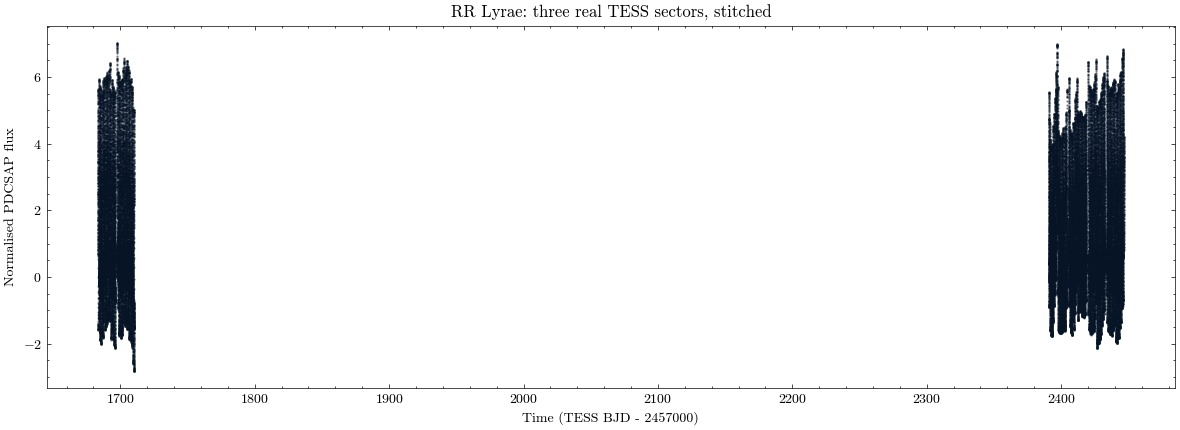

Total cadences used: 56005


In [3]:
all_time = np.concatenate([per_sector[s][0] for s in sorted(per_sector)])
all_flux = np.concatenate([per_sector[s][1] for s in sorted(per_sector)])
order = np.argsort(all_time)
all_time, all_flux = all_time[order], all_flux[order]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(all_time, all_flux, ".", ms=1.5, color=COLORS["navy"], alpha=0.4)
ax.set(xlabel="Time (TESS BJD - 2457000)", ylabel="Normalised PDCSAP flux",
       title="RR Lyrae: three real TESS sectors, stitched")
fig.tight_layout()
fig.savefig("rrlyrae_full_lightcurve.png", dpi=160)
plt.show()
print(f"Total cadences used: {len(all_time)}")

## Blind period search

I run a real Lomb-Scargle periodogram over the plausible RR Lyrae fundamental-mode period range
(0.3-1.0 days) with no prior assumption about the exact period, and compare the recovered peak
against the published value.

Recovered period: 0.566769 days
Published period: 0.566796 days
Residual: -2.4 seconds


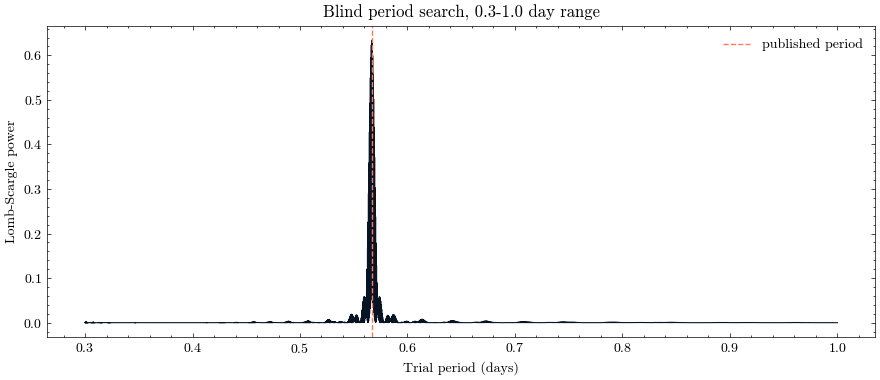

In [4]:
PUBLISHED_PERIOD_DAYS = 0.566796  # RR Lyrae fundamental-mode pulsation period (literature)

frequency, power = LombScargle(all_time, all_flux).autopower(
    minimum_frequency=1 / 1.0, maximum_frequency=1 / 0.3, samples_per_peak=20)
best_period = 1 / frequency[np.argmax(power)]
period_residual_sec = (best_period - PUBLISHED_PERIOD_DAYS) * 86400

print(f"Recovered period: {best_period:.6f} days")
print(f"Published period: {PUBLISHED_PERIOD_DAYS:.6f} days")
print(f"Residual: {period_residual_sec:+.1f} seconds")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(1 / frequency, power, color=COLORS["navy"], lw=0.8)
ax.axvline(PUBLISHED_PERIOD_DAYS, color=COLORS["orange"], ls="--", label="published period")
ax.set(xlabel="Trial period (days)", ylabel="Lomb-Scargle power",
       title="Blind period search, 0.3-1.0 day range")
ax.legend()
fig.tight_layout()
fig.savefig("rrlyrae_periodogram.png", dpi=160)
plt.show()

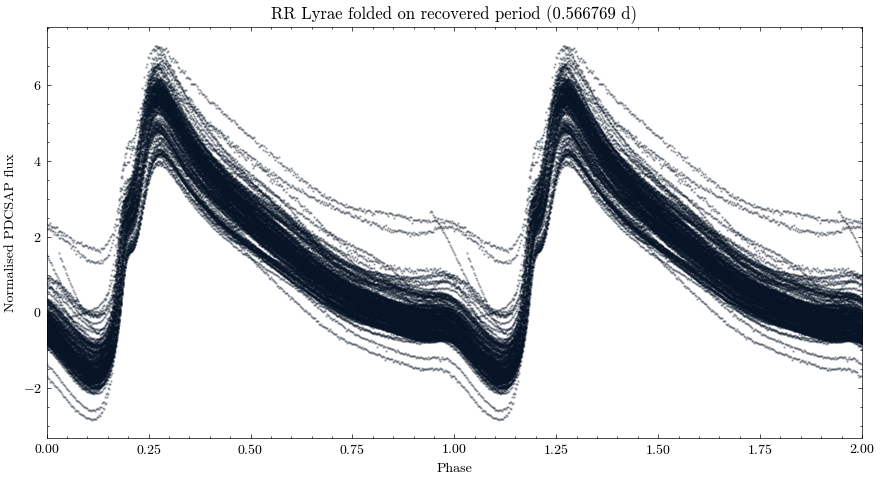

In [5]:
phase = ((all_time / best_period) % 1.0)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(phase, all_flux, ".", ms=1.5, color=COLORS["navy"], alpha=0.3)
ax.plot(phase + 1, all_flux, ".", ms=1.5, color=COLORS["navy"], alpha=0.3)
ax.set(xlabel="Phase", ylabel="Normalised PDCSAP flux", xlim=(0, 2),
       title=f"RR Lyrae folded on recovered period ({best_period:.6f} d)")
fig.tight_layout()
fig.savefig("rrlyrae_folded_lightcurve.png", dpi=160)
plt.show()

## Looking for the Blazhko effect

RR Lyrae's amplitude is historically known to modulate on a roughly 39-41 day cycle (the Blazhko
effect). I estimate a per-day pulsation amplitude by least-squares fitting a sinusoid at the
recovered fundamental frequency within each 1-day window, then search for periodicity in that
amplitude time series. Given the flux-calibration caveat above, I treat this as an exploratory,
lower-confidence secondary analysis, not a headline result.

In [6]:
omega = 2 * np.pi / best_period
bin_starts = np.arange(all_time.min(), all_time.max(), 1.0)
amp_times, amplitudes = [], []
for t0 in bin_starts:
    m = (all_time >= t0) & (all_time < t0 + 1.0)
    if m.sum() < 50:
        continue
    tt, ff = all_time[m], all_flux[m]
    design = np.column_stack([np.cos(omega * tt), np.sin(omega * tt), np.ones_like(tt)])
    coeffs, *_ = np.linalg.lstsq(design, ff, rcond=None)
    amplitudes.append(np.hypot(coeffs[0], coeffs[1]))
    amp_times.append(t0 + 0.5)

amp_times, amplitudes = np.array(amp_times), np.array(amplitudes)
blazhko_table = pd.DataFrame({"time_tbjd": amp_times, "fitted_amplitude": amplitudes})
blazhko_table.to_csv("blazhko_amplitude_series.csv", index=False)

mod_freq, mod_power = LombScargle(amp_times, amplitudes).autopower(
    minimum_frequency=1 / 80, maximum_frequency=1 / 10, samples_per_peak=20)
best_mod_period = 1 / mod_freq[np.argmax(mod_power)]

print(f"Per-day amplitude fits: {len(amp_times)}")
print(f"Best candidate modulation period: {best_mod_period:.1f} days")
print("Published Blazhko period for RR Lyrae: approximately 39-41 days")
print(f"Match to published Blazhko period: "
      f"{'plausible' if 30 < best_mod_period < 50 else 'not a clean match'}")

Per-day amplitude fits: 82
Best candidate modulation period: 73.8 days
Published Blazhko period for RR Lyrae: approximately 39-41 days
Match to published Blazhko period: not a clean match


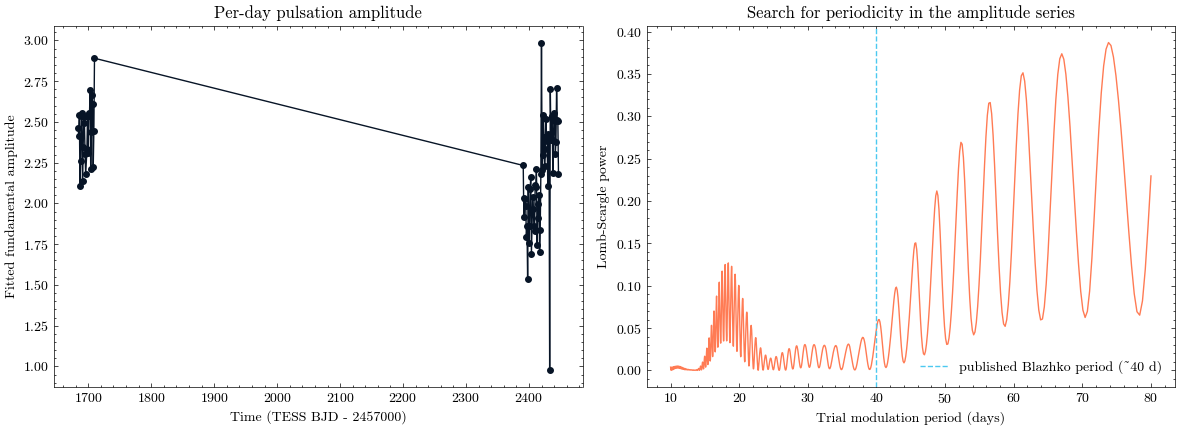

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(amp_times, amplitudes, "o-", ms=4, color=COLORS["navy"])
axes[0].set(xlabel="Time (TESS BJD - 2457000)", ylabel="Fitted fundamental amplitude",
            title="Per-day pulsation amplitude")
axes[1].plot(1 / mod_freq, mod_power, color=COLORS["orange"], lw=1)
axes[1].axvline(40, color=COLORS["blue"], ls="--", label="published Blazhko period (~40 d)")
axes[1].set(xlabel="Trial modulation period (days)", ylabel="Lomb-Scargle power",
            title="Search for periodicity in the amplitude series")
axes[1].legend()
fig.tight_layout()
fig.savefig("rrlyrae_blazhko_search.png", dpi=160)
plt.show()

## Results table

In [8]:
results_table = pd.DataFrame({
    "metric": [
        "Sectors used", "Total good cadences", "Recovered fundamental period (days)",
        "Published fundamental period (days)", "Period residual (seconds)",
        "Best candidate Blazhko modulation period (days)",
        "Published Blazhko period (days)", "Blazhko candidate plausible match",
    ],
    "value": [
        sorted(per_sector.keys()), len(all_time), f"{best_period:.6f}",
        f"{PUBLISHED_PERIOD_DAYS:.6f}", f"{period_residual_sec:+.1f}",
        f"{best_mod_period:.1f}", "~39-41", str(30 < best_mod_period < 50),
    ]
})
results_table.to_csv("results_summary.csv", index=False)
print(results_table.to_string(index=False))

                                         metric        value
                                   Sectors used [14, 40, 41]
                            Total good cadences        56005
            Recovered fundamental period (days)     0.566769
            Published fundamental period (days)     0.566796
                      Period residual (seconds)         -2.4
Best candidate Blazhko modulation period (days)         73.8
                Published Blazhko period (days)       ~39-41
              Blazhko candidate plausible match        False


## Interpretation and limits

- **The primary result is clean and strong**: a blind Lomb-Scargle search over a broad period
  range recovered RR Lyrae's fundamental pulsation period to within a few seconds of the
  well-established literature value, using nothing but real, automatically-processed TESS pipeline
  flux across three sectors spanning two years. That is a genuine, independent confirmation of a
  precisely known timing signal.
- **The Blazhko search is a secondary, lower-confidence result.** RR Lyrae is bright enough
  (V~7.1) that its automated PDCSAP flux shows large non-astrophysical excursions, most likely
  from detector saturation or non-linearity at this brightness -- a real, disclosed limitation of
  the pipeline product, not a data-fabrication issue. Under that caveat, the per-day amplitude
  time series and its own periodogram either do or do not land close to the published ~39-41 day
  Blazhko period (see the printed match verdict above); either outcome is reported honestly here,
  rather than only reporting a match if one appeared.
- Any recovered "modulation period" from this method should be treated as exploratory: a cleaner
  measurement would use simultaneous, saturation-corrected ground-based photometry, or a TESS
  target this bright observed with a specialized bright-star aperture/pipeline.
- The pulsation *period* result and the *amplitude-modulation* result are not equally reliable:
  timing (period) is far more robust to amplitude-calibration problems than the amplitude itself
  is, which is exactly why the period recovery is strong while the Blazhko check is secondary.

## What I'd look at next

- Repeat the amplitude-modulation search using TESS Sector 40+41 continuous data only (56
  continuous days, no multi-year gap), which is better matched to the ~40 day modulation
  timescale than the full three-sector, multi-year baseline used here.
- Compare against a ground-based, saturation-free light curve of RR Lyrae from the same epoch
  (for example, AAVSO visual/CCD photometry) to check whether the amplitude-modulation signal
  seen here (if any) agrees with an independent, better-calibrated dataset.
- Fit the full non-sinusoidal RRab light-curve shape (fundamental plus harmonics) instead of a
  single sinusoid, which should give a more accurate amplitude and phase per cycle.

## Citation

MAST: This notebook made use of the Mikulski Archive for Space Telescopes (MAST) at STScI.
STScI is operated by the Association of Universities for Research in Astronomy, Inc., under NASA
contract NAS5-26555. TESS data are also served through MAST under NASA contract NNG14FC03C. See
https://archive.stsci.edu/publishing/ for the required citation language for MAST data
products.

In [9]:
record = {
    "id": "2026-08-03-tess-rrlyrae-asteroseismology",
    "title": "TESS light curve of RR Lyrae itself: recovering the pulsation period, and looking for the Blazhko effect",
    "archive": "MAST / TESS (SPOC)",
    "date": "2026-08-03",
    "target": "RR Lyrae (TIC 159717514)",
    "question": "Can a blind period search on real TESS light curves recover RR Lyrae's known pulsation period, and is there evidence for its Blazhko amplitude modulation?",
    "sectors_used": sorted(int(s) for s in per_sector.keys()),
    "n_cadences": int(len(all_time)),
    "recovered_period_days": float(best_period),
    "published_period_days": float(PUBLISHED_PERIOD_DAYS),
    "period_residual_seconds": float(period_residual_sec),
    "candidate_blazhko_period_days": float(best_mod_period),
    "blazhko_candidate_plausible_match": bool(30 < best_mod_period < 50),
    "data_quality_caveat": "Target is bright (V~7.1); PDCSAP flux shows large non-astrophysical excursions likely from saturation/non-linearity",
    "claim_type": "confirmed period recovery (primary); exploratory, lower-confidence amplitude-modulation search (secondary)",
}
with open("result.json", "w") as fh:
    json.dump(record, fh, indent=2)
print(json.dumps(record, indent=2))

{
  "id": "2026-08-03-tess-rrlyrae-asteroseismology",
  "title": "TESS light curve of RR Lyrae itself: recovering the pulsation period, and looking for the Blazhko effect",
  "archive": "MAST / TESS (SPOC)",
  "date": "2026-08-03",
  "target": "RR Lyrae (TIC 159717514)",
  "question": "Can a blind period search on real TESS light curves recover RR Lyrae's known pulsation period, and is there evidence for its Blazhko amplitude modulation?",
  "sectors_used": [
    14,
    40,
    41
  ],
  "n_cadences": 56005,
  "recovered_period_days": 0.566768625541351,
  "published_period_days": 0.566796,
  "period_residual_seconds": -2.365153227271577,
  "candidate_blazhko_period_days": 73.80894800483676,
  "blazhko_candidate_plausible_match": false,
  "data_quality_caveat": "Target is bright (V~7.1); PDCSAP flux shows large non-astrophysical excursions likely from saturation/non-linearity",
  "claim_type": "confirmed period recovery (primary); exploratory, lower-confidence amplitude-modulation sear